In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import networkx as nx
import matplotlib.pyplot as plt


**LOADING DATASET**

In [2]:
df = pd.read_csv(
    "/kaggle/input/pima-indians-diabetes-database/diabetes.csv"
)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**EDA**

In [3]:
# Dataset shape and basic info
print("Dataset Shape:", df.shape)
display(df.head())

# Summary statistics
display(df.describe().T)

# Target distribution
df["Outcome"].value_counts(normalize=True)


Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

In [4]:
# Check invalid zero values (medical context)
invalid_zero_cols = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]

invalid_zero_summary = (df[invalid_zero_cols] == 0).sum()
display(invalid_zero_summary)

# Correlation with target
display(
    df.corr()["Outcome"]
    .sort_values(ascending=False)
)



Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

**PREPROCESSING**

In [5]:
# Copy dataset to avoid modifying original
data = df.copy()

# Replace invalid zeros with NaN
cols_with_invalid_zero = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]

data[cols_with_invalid_zero] = data[cols_with_invalid_zero].replace(0, np.nan)

for col in invalid_zero_cols:
    data[col] = data[col].fillna(data[col].median())

In [6]:

# Feature-target split
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

**Neural Network Model**

In [8]:
class DiabetesNet(nn.Module):
    """
    Neural network that predicts diabetes risk probability
    """
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


In [9]:
model = DiabetesNet(X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [10]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47


In [11]:
best_loss = float('inf')
patience = 3
counter = 0

for epoch in range(1000):
    optimizer.zero_grad()
    
    preds = model(X_train)
    loss = criterion(preds, y_train)
    
    loss.backward()
    optimizer.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Stopping early at epoch {epoch}")
        break

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 0.6944
Epoch 5, Loss: 0.6863
Epoch 10, Loss: 0.6782
Epoch 15, Loss: 0.6698
Epoch 20, Loss: 0.6609
Epoch 25, Loss: 0.6510
Epoch 30, Loss: 0.6399
Epoch 35, Loss: 0.6274
Epoch 40, Loss: 0.6137
Epoch 45, Loss: 0.5988
Epoch 50, Loss: 0.5829
Epoch 55, Loss: 0.5667
Epoch 60, Loss: 0.5505
Epoch 65, Loss: 0.5347
Epoch 70, Loss: 0.5198
Epoch 75, Loss: 0.5063
Epoch 80, Loss: 0.4946
Epoch 85, Loss: 0.4847
Epoch 90, Loss: 0.4766
Epoch 95, Loss: 0.4701
Epoch 100, Loss: 0.4649
Epoch 105, Loss: 0.4606
Epoch 110, Loss: 0.4570
Epoch 115, Loss: 0.4538
Epoch 120, Loss: 0.4509
Epoch 125, Loss: 0.4482
Epoch 130, Loss: 0.4456
Epoch 135, Loss: 0.4432
Epoch 140, Loss: 0.4409
Epoch 145, Loss: 0.4386
Epoch 150, Loss: 0.4365
Epoch 155, Loss: 0.4345
Epoch 160, Loss: 0.4325
Epoch 165, Loss: 0.4305
Epoch 170, Loss: 0.4285
Epoch 175, Loss: 0.4264
Epoch 180, Loss: 0.4244
Epoch 185, Loss: 0.4223
Epoch 190, Loss: 0.4203
Epoch 195, Loss: 0.4183
Epoch 200, Loss: 0.4162
Epoch 205, Loss: 0.4142
Epoch 210, Los

In [12]:
RULES = {
    "High Glucose": {
        "feature": "Glucose",
        "threshold": 140,
        "weight": 1.0,
        "risk_type": "Metabolic Risk"
    },
    "High BMI": {
        "feature": "BMI",
        "threshold": 30,
        "weight": 0.8,
        "risk_type": "Obesity Risk"
    },
    "High Age": {
        "feature": "Age",
        "threshold": 45,
        "weight": 0.6,
        "risk_type": "Demographic Risk"
    },
    "High Neural Risk": {
        "feature": "Neural",
        "threshold": 0.7,
        "weight": 1.2,
        "risk_type": "Model Risk"
    }
}


In [13]:
def apply_medical_rules(row, neural_prob):
    activated_rules = []

    for rule, meta in RULES.items():
        if meta["feature"] == "Neural":
            value = neural_prob
        else:
            value = row[meta["feature"]]

        if value > meta["threshold"]:
            activated_rules.append({
                "rule": rule,
                "weight": meta["weight"],
                "risk_type": meta["risk_type"]
            })

    return activated_rules


In [14]:
def build_knowledge_graph(activated_rules):
    G = nx.DiGraph()

    # Core nodes
    G.add_node("Patient", type="Entity")
    G.add_node("Diabetes", type="Disease")

    # Risk layer
    risk_nodes = set(r["risk_type"] for r in activated_rules)

    for risk in risk_nodes:
        G.add_node(risk, type="Risk")
        G.add_edge("Patient", risk)

    # Rule layer
    for r in activated_rules:
        rule_node = r["rule"]
        G.add_node(rule_node, weight=r["weight"], type="Rule")
        G.add_edge(r["risk_type"], rule_node)
        G.add_edge(rule_node, "Diabetes")

    return G


In [15]:
def compute_graph_risk(G):
    total_score = 0
    count = 0

    for node, data in G.nodes(data=True):
        if data.get("type") == "Rule":
            total_score += data["weight"]
            count += 1

    if count == 0:
        return 0.0

    return total_score / count


In [16]:
def final_decision(neural_prob, graph_risk):
    """
    Final interpretable decision logic
    """
    # Symbolic gate
    if graph_risk >= 0.7:
        decision = 1
    elif neural_prob >= 0.75:
        decision = 1
    else:
        decision = 0

    final_score = 0.6 * neural_prob + 0.4 * graph_risk
    return final_score, decision


In [17]:
model.eval()
with torch.no_grad():
    probs = model(X_test).squeeze()

X_test_df = pd.DataFrame(
    scaler.inverse_transform(X_test.numpy()),
    columns=X.columns
)

final_results = []

for i in range(5):
    neural_prob = probs[i].item()
    patient_data = X_test_df.iloc[i]

    # Symbolic reasoning
    activated_rules = apply_medical_rules(patient_data, neural_prob)
    G = build_knowledge_graph(activated_rules)
    graph_risk = compute_graph_risk(G)

    # Final decision
    final_score, decision = final_decision(neural_prob, graph_risk)

    # Human-readable explanation
    rule_names = [r["rule"] for r in activated_rules]
    risk_types = list(set(r["risk_type"] for r in activated_rules))

    explanation = (
        f"Neural model predicted {round(neural_prob,2)} probability. "
        f"Symbolic reasoning identified risks: {', '.join(risk_types)}. "
        f"Activated rules: {', '.join(rule_names)}."
        if rule_names else
        "No significant medical rules were triggered."
    )

    final_results.append({
        "Neural_Probability": round(neural_prob, 3),
        "Symbolic_Graph_Risk": round(graph_risk, 3),
        "Final_Fused_Score": round(final_score, 3),
        "Diabetes_Prediction": "Positive" if decision == 1 else "Negative",
        "Activated_Rules": rule_names,
        "Risk_Categories": risk_types,
        "Explanation": explanation
    })

pd.DataFrame(final_results)


,Neural_Probability,Symbolic_Graph_Risk,Final_Fused_Score,Diabetes_Prediction,Activated_Rules,Risk_Categories,Explanation
0,1.000,1.0,1.000,Positive,"[High BMI, High Neural Risk]","[Model Risk, Obesity Risk]",Neural model predicted 1.0 probability. Symbol...
1,0.001,0.8,0.321,Positive,[High BMI],[Obesity Risk],Neural model predicted 0.0 probability. Symbol...
2,0.065,0.8,0.359,Positive,[High BMI],[Obesity Risk],Neural model predicted 0.07 probability. Symbo...
3,0.128,0.0,0.077,Negative,[],[],No significant medical rules were triggered.
4,0.979,0.9,0.948,Positive,"[High Age, High Neural Risk]","[Model Risk, Demographic Risk]",Neural model predicted 0.98 probability. Symbo...


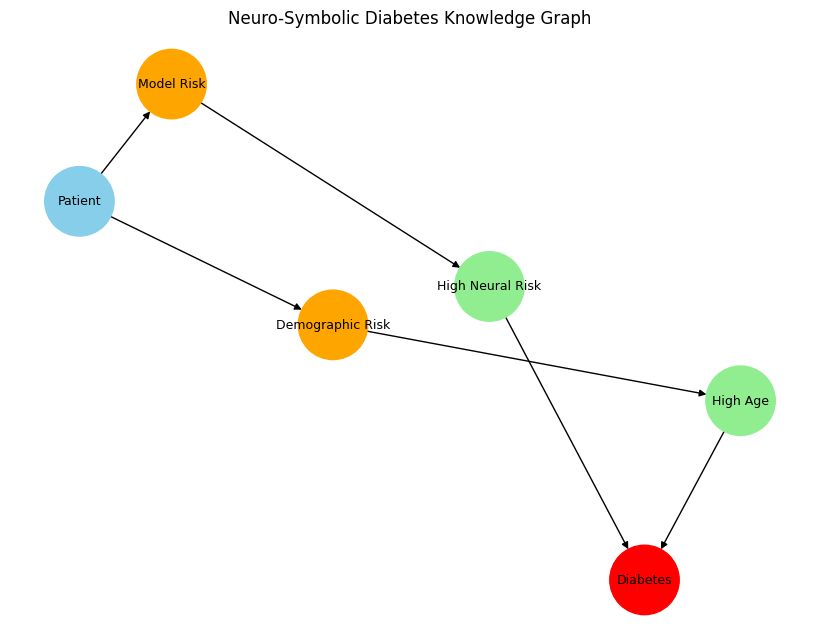

In [18]:
def visualize_graph(G):
    pos = nx.spring_layout(G, seed=42)

    color_map = []
    for node in G:
        if G.nodes[node]["type"] == "Disease":
            color_map.append("red")
        elif G.nodes[node]["type"] == "Risk":
            color_map.append("orange")
        elif G.nodes[node]["type"] == "Rule":
            color_map.append("lightgreen")
        else:
            color_map.append("skyblue")

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos,
            with_labels=True,
            node_color=color_map,
            node_size=2500,
            font_size=9)
    plt.title("Neuro-Symbolic Diabetes Knowledge Graph")
    plt.show()
visualize_graph(G)

**Patient
  ↓
Clinical Factors (Glucose, BMI, Age, BP)
  ↓
Medical Risk States
  ↓
Diabetes Risk
**

In [19]:
final_results

[{'Neural_Probability': 1.0,
  'Symbolic_Graph_Risk': 1.0,
  'Final_Fused_Score': 1.0,
  'Diabetes_Prediction': 'Positive',
  'Activated_Rules': ['High BMI', 'High Neural Risk'],
  'Risk_Categories': ['Model Risk', 'Obesity Risk'],
  'Explanation': 'Neural model predicted 1.0 probability. Symbolic reasoning identified risks: Model Risk, Obesity Risk. Activated rules: High BMI, High Neural Risk.'},
 {'Neural_Probability': 0.001,
  'Symbolic_Graph_Risk': 0.8,
  'Final_Fused_Score': 0.321,
  'Diabetes_Prediction': 'Positive',
  'Activated_Rules': ['High BMI'],
  'Risk_Categories': ['Obesity Risk'],
  'Explanation': 'Neural model predicted 0.0 probability. Symbolic reasoning identified risks: Obesity Risk. Activated rules: High BMI.'},
 {'Neural_Probability': 0.065,
  'Symbolic_Graph_Risk': 0.8,
  'Final_Fused_Score': 0.359,
  'Diabetes_Prediction': 'Positive',
  'Activated_Rules': ['High BMI'],
  'Risk_Categories': ['Obesity Risk'],
  'Explanation': 'Neural model predicted 0.07 probabilit